In [68]:
from ucimlrepo import fetch_ucirepo 
  
iris = fetch_ucirepo(id=53) 
  
features = iris.data.features 
targets = iris.data.targets 

In [ ]:
from sklearn.cluster import KMeans
from sklearn.cluster import AgglomerativeClustering
from sklearn.preprocessing import StandardScaler
import matplotlib.pyplot as plt

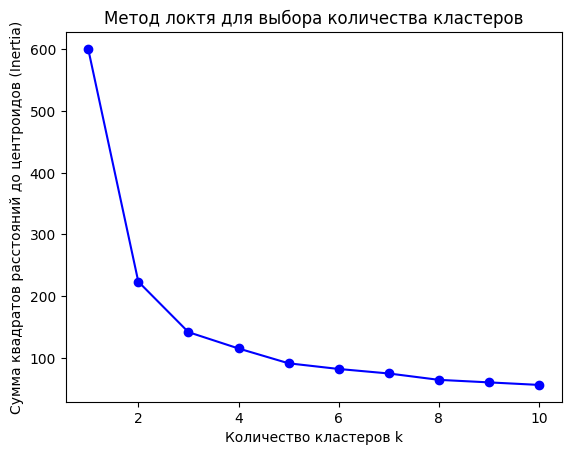

In [103]:
scaler = StandardScaler()
features = scaler.fit_transform(features)

inertia = []
K = range(1, 11)
for k in K:
    kmeans = KMeans(n_clusters=k, random_state=420)
    kmeans.fit(features)
    inertia.append(kmeans.inertia_)


plt.plot(K, inertia, 'bo-')
plt.xlabel('Количество кластеров k')
plt.ylabel('Сумма квадратов расстояний до центроидов (Inertia)')
plt.title('Метод локтя для выбора количества кластеров')
plt.show()

In [87]:
def plotClusters(cluster_type, values, title, ix):
    plt.figure(figsize=(15, 5))
    plt.subplot(1, 2, ix)
    plt.scatter(values[:, 0], values[:, 1], c=cluster_type, cmap='viridis')
    plt.title(title)

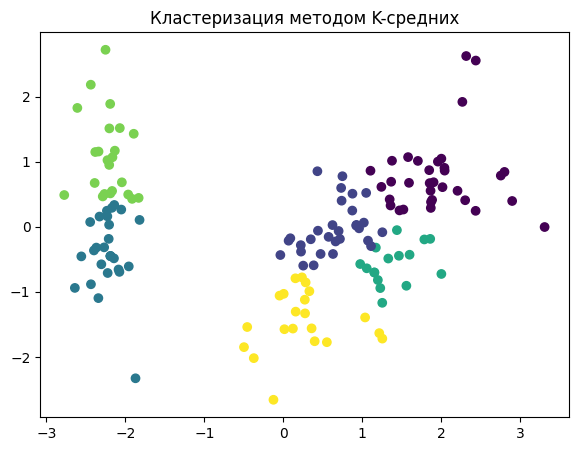

In [126]:
from sklearn.decomposition import PCA
kmeans = KMeans(n_clusters=6, random_state=420, init='random')
clusters_kmeans = kmeans.fit_predict(features)
pca = PCA(n_components=2)
X_pca = pca.fit_transform(features)
plotClusters(clusters_kmeans, X_pca, 'Кластеризация методом K-средних', 1)


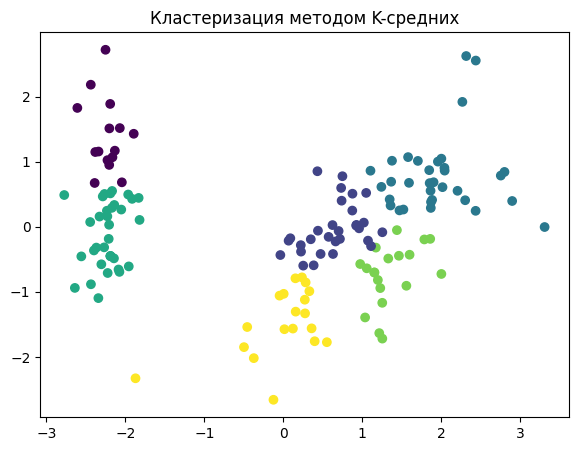

In [127]:
kmeans = KMeans(n_clusters=6)
clusters_kmeans = kmeans.fit_predict(features)
plotClusters(clusters_kmeans, X_pca, 'Кластеризация методом K-средних', 1)

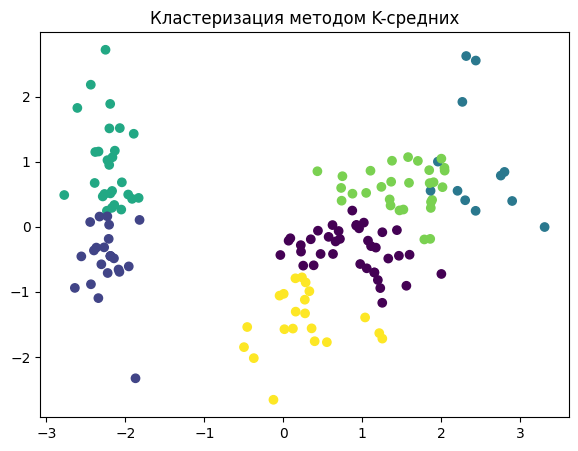

In [165]:
kmeans = KMeans(n_clusters=6, max_iter=1000, n_init=50)
clusters_kmeans = kmeans.fit_predict(features)
plotClusters(clusters_kmeans, X_pca, 'Кластеризация методом K-средних', 1)

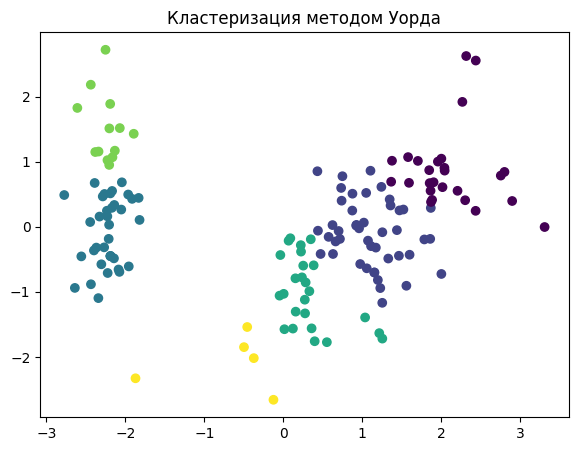

In [107]:
ward = AgglomerativeClustering(n_clusters=6, linkage='ward')
clusters_ward = ward.fit_predict(features)
plotClusters(clusters_ward, X_pca, 'Кластеризация методом Уорда', 2)

In [ ]:
ward = AgglomerativeClustering(n_clusters=6, linkage='ward', metric='manhattan')
clusters_ward = ward.fit_predict(features)
plotClusters(clusters_ward, X_pca, 'Кластеризация методом Уорда', 2)